## Entity-sentiment pipeline: parse-based tagging, coreference, and aspect-based sentiment

Notebook 2.1 ended by making the pipeline cheap. Its section 8 recorded the change that mattered
most: a single shared predicate, `needs_score()`, meant we stopped paying FinBERT to score four
sentences in five that no feature ever read -- a 61.5% cut in forward passes, roughly twice the
speed, and a feature table that came out bit-identical to the one the full-scoring path produced.
Together with the on-disk caches -- and with the cache-truncation bug that had been silently
re-paying for a full FinBERT pass on every run -- that is what bought the processing budget this
notebook spends. Three waves of work follow, and none of them would have been affordable against a
pipeline that took twenty minutes to answer a question:

- **Wave 4 -- keeping the parse.** The spaCy dependency parse was already being computed to split
  sentences and then thrown away. Now it is kept, and it pays for itself three times: the company in
  *subject position* wins the antecedent instead of the one mentioned first, spaCy's `ORG` entities
  catch the long tail of companies no curated registry will ever cover (**since removed --
  see 1.2**), and company descriptors
  ("the automaker") resolve to whichever company actually bears them rather than defaulting to the
  target.
- **Wave 5 -- coreference.** The anaphora heuristic -- most-recently-named company, with a decay
  window -- hand-scored at roughly 60% accuracy and supplied about a third of all target sentences,
  which made it the largest known accuracy deficit in the pipeline. A real coreference model reads
  the mention chain instead of guessing at recency.
- **Wave 6 -- aspect-based sentiment.** FinBERT scores a *sentence*. We keep asking it a question
  about a *company*, and those two come apart exactly where it hurts: "Build-A-Bear outperformed
  Tesla" is a positive sentence and reads as good news about Tesla. An aspect-based model is handed
  the aspect term explicitly and scores sentiment toward it.

This notebook documents all three with before/after measurements, then does something 2.1 did not:
it **audits the aspect-based substitution against a fresh sample** and reports a defect class that
survived the previous session's fixes. It closes on the honest limitation -- that every validation
in this project so far, this notebook included, is an eyeball check.

**Inputs:** `data/processed/processed_articles.parquet` (unchanged since 1.2), plus the existing
`data/sentences.parquet` / `data/articles.parquet` as the "before" snapshot.

**Outputs:** those same two files, overwritten with the post-Wave-6 run. (This notebook also wrote
`references/goldset-sample.csv` and `references/goldset-predictions.csv`; the gold set was never
labelled and has since been removed — see 9.1.)

### 0. Loading the corpus and the pre-2.3 snapshot

Same snapshot discipline as 2.1: this notebook overwrites `data/sentences.parquet` and
`data/articles.parquet` in section 6, so the first run copies them aside to
`data/interim/*_before_2.3.parquet` and every later re-run reads the copies. Without that, a second
execution would compare the new run against itself and every delta would read as zero.

In [1]:
import json
import time

import pandas as pd
import matplotlib.pyplot as plt

from stock_predictor.config import (
    DATA_DIR,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    PRIMARY_TICKER,
    REPORTS_DIR,
    PROJ_ROOT,
)
from stock_predictor.text import absa, coref, entity_filter, sentiment

pd.set_option("display.max_colwidth", 200)

articles = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
print("corpus:", articles.shape)

before_sentences_path = INTERIM_DATA_DIR / "sentences_before_2.3.parquet"
before_articles_path = INTERIM_DATA_DIR / "articles_before_2.3.parquet"

if not before_sentences_path.exists():
    pd.read_parquet(DATA_DIR / "sentences.parquet").to_parquet(before_sentences_path, index=False)
if not before_articles_path.exists():
    pd.read_parquet(DATA_DIR / "articles.parquet").to_parquet(before_articles_path, index=False)

sentences_before = pd.read_parquet(before_sentences_path)
articles_before = pd.read_parquet(before_articles_path)
print("sentences_before:", sentences_before.shape)
print("articles_before:", articles_before.shape)

2026-08-16 11:01:06.447 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


corpus: (2124, 8)
sentences_before: (71410, 24)
articles_before: (2124, 46)


## 1. Wave 4 -- keeping the parse

Every sentence in this corpus was already being run through spaCy's dependency parser, because that
is what finds the sentence boundaries. Until Wave 4 we took the boundaries and discarded the parse.
That was leaving three separate signals on the floor.

### 1.1 Subject position beats first mention

When several companies appear in one sentence, which one does a following "The company..." refer
to? 2.1 answered *the one mentioned first*, which was never a principled rule -- it was a positional
proxy adopted because no parse was available. With the parse kept, we can ask the real question:
which company is the grammatical **subject**?

In [2]:
demo = [
    "According to Ford, Tesla is expanding its Berlin plant.",
    "The company said the expansion would add capacity.",
]
tagged = entity_filter.tag_sentences("demo_subject", demo, PRIMARY_TICKER)
tagged[["sent_idx", "text", "mentions_target", "mentions_other", "target_is_subject", "resolved_by_anaphora"]]

2026-08-16 11:01:12.424 | INFO     | stock_predictor.text.entity_filter:_get_nlp:112 - Loading spaCy model 'en_core_web_sm' (excluding lemmatizer; ner enabled)


,sent_idx,text,mentions_target,mentions_other,target_is_subject,resolved_by_anaphora
0,0,"According to Ford, Tesla is expanding its Berlin plant.",True,True,True,False
1,1,The company said the expansion would add capacity.,True,False,False,True


Ford is named first; Tesla is the subject. The antecedent goes to Tesla, so the following sentence
is tagged as a Tesla sentence -- which is what a reader would say it is about. A `target_is_subject`
column now records this per sentence, because a sentence whose grammatical subject is the target is
far more likely to be genuinely about the target, and that is worth keeping as a signal in its own
right rather than consuming and discarding.

In plain terms: we used to guess which company a sentence was about by seeing which name came first,
which gets "According to Ford, Tesla..." exactly backwards. Now we use the grammar to see which
company the sentence is actually *about*.

### 1.2 NER for the companies nobody would curate -- and why it had to be tightened

> **SUPERSEDED -- this mechanism was removed.** The ORG-based other-company detector described
> below no longer exists. `other_source` is now only `"registry"` or `""`, and an unregistered
> company gets no tag at all. The section is kept as written because the *reasoning* is what
> justified building it, and the reason it was removed is only legible against that argument.
>
> **Why it went.** NER was added here to stop sentences naming unregistered companies from
> contaminating Tesla's sentiment -- necessary because FinBERT scores a whole *sentence* and cannot
> tell whose sentiment it is. Wave 6 (section 3 below) added ABSA, which scores sentiment *toward
> an aspect*, and that supersedes the justification directly.
>
> What the detector still did in practice was populate `mentions_other` for the
> `sent_other_mean_*` / `absa_other_mean_*` family at the 50-65% precision this section itself
> reports -- noise flagged in section 8's limitations and never validated. Measured: of 10,502
> NER-sourced non-boilerplate rows, only **1,369** also carried `mentions_target` (the
> contamination case ABSA now handles); the other **9,133** existed purely to feed that family.
>
> Its second justification also lapsed. A NER company could anchor the antecedent in subject
> position, but `last_named` is read *only* by the anaphora heuristic, and 2.6 switched that off
> at 13% measured precision. That path was already dead.
>
> **One thing that did NOT go: spaCy's `ner` component is still enabled.** `PERSON` entities are
> load-bearing for coreference keying (they stop "Tesla CEO Elon Musk" keying a whole Musk chain to
> Tesla) and for the substitution guard. See `entity_filter._get_nlp()`, which says so in a comment
> for exactly this reason.

The `COMPANIES` registry is a precision instrument with terrible recall on the tail. Hand-checking
the tagged corpus showed the residual "this sentence is really about someone else" contamination was
dominated by firms no one would think to curate in advance -- Avidity Biosciences, Samsung. spaCy's
`ORG` entities cover that tail for free now that the parse is kept, and an `other_source` column
records whether a tag came from the registry or from NER, so the two never blur together.

Turning NER on and leaving it alone would have been a mistake. Inspection showed it over-firing
badly, and the fixes are worth stating because they follow one principle: **the cost of a false
positive is not symmetric across features.**

- **`is_comparative` is registry-only.** It drives an *exclusion* (`sent_entity_excl_comp_*`), so
  every false positive **deletes** a real, usually strongly polarised, target sentence from the
  feature. `mentions_other` is additive -- a false positive merely widens a contrast set. Measured
  NER precision on "is this another company" is roughly 50-65%: good enough to widen coverage,
  nowhere near good enough to gate the removal of real signal. On a 400-article sample this dropped
  `is_comparative` from 5.09% to 2.83%, with the registry-driven count identical (381) before and
  after -- i.e. everything it removed was NER noise.
- **A NER company anchors the antecedent only in subject position.** "...according to data tracked
  by Wells Fargo's Colin Langan" names a company inside an attribution; letting it anchor
  `last_named` hands the following sentences to a firm the article is not discussing.
- **Product names moved out of the global stoplist and into the registry.** `NER_ORG_STOPLIST` had
  acquired `fsd`, `autopilot`, `cybertruck`, `model y` -- one company's product catalogue hardcoded
  into a shared constant, which is precisely the ticker-agnostic constraint the `COMPANIES` registry
  exists to satisfy. They now live on their company's entry as a `products` tier, and the union of
  every entry's products is suppressed on every run: a product is never a company under discussion,
  so whose product it is does not matter.
- **Person names and full-form regulators are filtered.** "Wood took advantage of Tesla's 52-week
  low" was tagging Cathie Wood as a company; only regulator *acronyms* were blocked, not their full
  names, so "the National Highway Traffic Safety Administration (NHTSA)" read as a rival.

In [3]:
ner_demo = [
    "Avidity Biosciences surged after its trial readout, while Tesla slipped.",
    "Tesla's FSD faces scrutiny from the National Highway Traffic Safety Administration (NHTSA).",
    "Wood took advantage of Tesla's 52-week low.",
]
ner_tagged = entity_filter.tag_sentences("demo_ner", ner_demo, PRIMARY_TICKER)
ner_tagged[["text", "mentions_target", "mentions_other", "other_source", "other_key", "is_comparative"]]

,text,mentions_target,mentions_other,other_source,other_key,is_comparative
0,"Avidity Biosciences surged after its trial readout, while Tesla slipped.",True,False,,,False
1,Tesla's FSD faces scrutiny from the National Highway Traffic Safety Administration (NHTSA).,True,False,,,False
2,Wood took advantage of Tesla's 52-week low.,True,False,,,False


**As the pipeline stands today**, none of the three sentences produces an other-company tag: all
three are `mentions_target` only. Avidity Biosciences is not in `COMPANIES`, so it is invisible to
the tagger -- where it previously set `mentions_other` with `other_source == "ner"`. The regulator
and the person name produce no tag either, as they did before, but now by construction rather than
by a stoplist and a PERSON filter.

*The paragraph this cell used to carry, describing the NER tag on sentence 1, is preserved in the
superseded banner above.*

In plain terms: we used to let spaCy find the companies our curated list missed, and accept its
mistakes wherever they were cheap. Scoring toward the company directly turned out to be a better
answer to the same problem, so the guesswork is gone -- at the cost of a narrower, cleaner
`sent_other_mean_*`.

### 1.3 Descriptors resolve to whoever actually bears them

"The automaker" used to be a hard explicit match on the target. That is wrong in both directions: in
a Ford-heavy article it scored as Tesla, and under `ticker="F"` the phrase kept its Tesla reading.
Descriptors are now anaphoric and **scoped**: the set of registry entries listing a phrase *is* the
set of companies it may resolve to, and it resolves to the most recently named one of those, subject
to the same decay window. If none is in range it resolves to **neither** -- it never falls back to
the target.

In [4]:
descriptor_demo = [
    "Ford reported a strong quarter for its truck division.",
    "The automaker also raised its full-year guidance.",
]
desc_tagged = entity_filter.tag_sentences("demo_descriptor", descriptor_demo, PRIMARY_TICKER)
desc_tagged[["text", "mentions_target", "mentions_other", "resolved_by_anaphora"]]

,text,mentions_target,mentions_other,resolved_by_anaphora
0,Ford reported a strong quarter for its truck division.,False,True,False
1,The automaker also raised its full-year guidance.,False,True,True


Under `ticker="TSLA"`, "The automaker" here resolves to Ford -- so the sentence is an *other*
sentence, not a Tesla one. Before Wave 4 it was a Tesla sentence, and its sentiment was credited to
Tesla. Expect `mentions_target` to fall as a result of this change: that is the correction, not a
regression.

In plain terms: "the automaker" means whichever car company we were just talking about, not
automatically the one we happen to be tracking.

## 2. Wave 5 -- coreference

The anaphora heuristic hands an un-named sentence ("The company also raised prices.") to whichever
company was named most recently, with a decay window so a stale antecedent does not drift forever.
It hand-scored at roughly 60% accuracy and supplied about a third of all target sentences. Its two
known failure modes are exactly the ones recency cannot express: multi-company roundups, where the
nearest named company is incidental rather than the topic, and attribution buried in subordinate
clauses, where the grammatically nearest company is not the one the pronoun refers back to.

`stock_predictor/text/coref.py` wraps `fastcoref` (F-Coref, ~90M parameters, CPU by design) and
reads the actual mention chain. Three properties of how it is wired in matter more than the model
choice:

- **Graceful degradation.** If the backend is missing or inference raises, one warning is logged and
  every sentence falls back to the heuristic. The pipeline never hard-fails because coreference is
  unavailable.
- **Separate columns.** `resolved_by_coref` and `resolved_by_anaphora` are mutually exclusive by
  construction, so the two mechanisms stay independently measurable rather than merged into one
  unattributable number.
- **Character offsets, not token indices.** The spans address the exact cleaned string the sentence
  Spans were parsed from, and `process_articles()` asserts that identity rather than assuming it.
  This is load-bearing for Wave 6, which substitutes a name over those characters.

In [5]:
print("coref backend available:", coref.is_available())
coref_cache = coref.load_cache()
print("coref cache entries:", len(coref_cache))

D:\ML\stock-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


08/16/2026 11:01:20 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


08/16/2026 11:01:20 - WARNING - 	 Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


08/16/2026 11:01:20 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"


2026-08-16 11:01:20.171 | INFO     | stock_predictor.text.coref:_load_model:114 - Loading coreference model 'biu-nlp/f-coref' (CPU)


...

08/16/2026 11:01:21 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/main "HTTP/1.1 200 OK"


08/16/2026 11:01:21 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/discussions?p=0 "HTTP/1.1 200 OK"


2026-08-16 11:01:21.458 | INFO     | stock_predictor.text.coref:_load_model:116 - Coreference model loaded
coref backend available: True


08/16/2026 11:01:21 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"


coref cache entries: 2073


### 2.1 Two person-chain bugs, found by adjudicating disagreements by hand

Both were found the same way: sample the sentences where coref and the heuristic *disagree*, and
read them. Neither would have surfaced from aggregate statistics, and neither appeared in the
implementing agent's own summary of its work.

1. **A mention like "Tesla CEO Elon Musk" contains "Tesla",** so a plain substring test keyed an
   entire *person* chain to the company. Article 140122179 is a story about Musk's lawsuit against
   Sam Altman -- nothing to do with Tesla -- and "Kalshi's similar market has Musk winning at 55%."
   was tagged as a Tesla sentence purely because the Musk chain contained that appositive. That
   silently bypassed a design decision predating coref entirely: `mentions_target` has never been
   settable by a person-tier match, because a Musk sentence may be about SpaceX or X rather than
   Tesla. Fixed by refusing to key a cluster from a mention overlapping a `PERSON` entity.
2. **The residual case has no `PERSON` entity at all.** "the Tesla CEO", "The Tesla Inc. (NASDAQ:
   TSLA) CEO", "the Tesla billionaire's" are appositive *title* phrases naming a person purely by
   their company. Fixed with a job-title token rule.

Both fixes are **keying-only**. A person-like mention still belongs to its cluster and still tags its
sentence if some other mention resolves the chain. Measured on the corpus, the pair removed ~174
`mentions_target` sentences.

In plain terms: the model was reading "Tesla CEO Elon Musk" and concluding that every later "he" in
the article was a sentence about Tesla. It is a person, not the company, and we had a rule about
that already -- coreference had found a back door around it.

### 2.2 Caching, because coreference is the most expensive stage

Coref inference is deterministic in the document text and cost ~833s over this corpus -- more than
FinBERT. It is cached to `data/interim/coref_cache.parquet` keyed on a hash of the exact string
coref saw, with the clusters serialised to JSON. **Cold 833s, warm 0.2s**, and the cold and warm tag
tables were asserted byte-identical. Like every cache in this project, saves **merge** with the
cache loaded at the start of the call and never replace it -- `sentiment.py` had a truncation bug
from replacing, and the same shape of bug here would silently throw away a full corpus run.

## 3. Wave 6 -- aspect-based sentiment

FinBERT scores a sentence. The pipeline asks how a sentence reads **about the target company**.
2.0 measured the gap and could only respond by *deleting* the offending sentences, which is what
`sent_entity_excl_comp_*` is. An aspect-based model
(`yangheng/deberta-v3-base-absa-v1.1`) is handed the aspect term explicitly and scores sentiment
toward it, so the comparative sentence can be kept and read correctly instead.

This runs **alongside** FinBERT, never instead of it: every `absa_*` column is parallel to an
existing `sent_*` one, reading exactly the same four sentence selections, so a difference between a
pair is a difference between the two *models* and never between two populations.

### 3.1 Pairs, and the substitution that makes them work

An ABSA model attends to an aspect **term that must be present in the text**; it is not a classifier
over an abstract entity id. An anaphoric sentence -- "The company also raised prices." -- contains no
company name to attend to. So the resolved name is injected over the anaphor's own characters, using
the spans Wave 5 records for exactly this purpose:

    "The company also raised prices."  ->  "Tesla also raised prices."

**This makes ABSA quality dependent on antecedent quality.** A wrong antecedent no longer merely
mis-files a correct score; it changes the sentence the model reads, and the model will
*confidently* score toward the wrongly injected entity. That dependency is why coreference had to
land before this module rather than after it. It is also why section 5 below exists.

### 3.2 The adjudicated evidence, and the thing it accidentally revealed

We took the sentences where FinBERT and ABSA disagreed most and read them by hand.

**On 15 comparative sentences with the largest disagreement, ABSA was correct on all 15.**

| sentence | FinBERT | ABSA | correct toward Tesla |
|---|---|---|---|
| "BYD capitalized on Tesla's weakness" | **+0.93** | **-0.94** | ABSA |
| "Ford and GM posted stellar beats... Tesla missed on adjusted profits" | **+0.86** | **-0.98** | ABSA |
| "Rivian's $19bn market cap pales in comparison to Tesla's $1.2 trillion valuation" | **-0.94** | **+0.95** | ABSA |

The third is the interesting one: FinBERT is misled by the word "pales" into reading the sentence as
negative, when the sentence is *favourable* to Tesla.

The control list -- 10 **non**-comparative sentences -- was meant to expose a domain-mismatch
penalty, since ABSA is trained on SemEval product reviews and FinBERT on financial text. **It did the
opposite**, and revealed something more important than the comparative result:

| sentence | FinBERT | ABSA |
|---|---|---|
| "The ETF is up 28% YTD, though it has cooled on Tesla weakness" | **+0.92** | **-0.99** |
| "the ETF gaining roughly 38% as Tesla shares retreated" | **+0.91** | **-0.98** |
| "Tesla is graded F on this front" | **+0.92** | **-0.97** |

None of these is a two-company comparison, so none is caught by `is_comparative`. **The
contamination class is much larger than the 3.11% `is_comparative` measures.** It is any sentence
pairing the target with a benchmark, an ETF, a peer average, or a grade. `is_comparative` measures a
symptom; `sent_entity_excl_comp_*` only ever covered a fraction of the disease.

In plain terms: we built a flag to catch sentences where Tesla is compared to a rival, and then
discovered the same problem shows up whenever Tesla is compared to *anything* -- an index, a fund, a
letter grade. Deleting the sentences we could detect was never going to fix that. Scoring toward the
company might.

## 4. Auditing the substitution

Everything above was inherited. This section is new work, and it starts from a loose end: nobody had
eyeballed a fresh sample of substituted sentences since the last round of grammar fixes went in.
Since section 3.1 makes ABSA's anaphoric scores entirely dependent on what gets injected, that
sample is not optional before trusting them.

The previous session found and fixed four defects: expletive "it" being substituted ("It's no
coincidence that..." becoming "Tesla's no coincidence that..."), possessives producing broken
grammar ("Its revenue" becoming "Tesla revenue" rather than "Tesla's revenue"), person mentions being
overwritten with the company name, and NER-sourced other-companies having no usable aspect at all.
All four are genuinely fixed -- they have tests, and the corpus numbers reproduce.

Reading a fresh sample turned up a **fifth defect class that none of those four fixes addresses**,
because each of them patched one *named* failure and nothing constrained the injected span to be a
referring expression for a company in general.

In [6]:
# The pre-2.3 snapshot is the unaudited state: every row where the injected text
# differs from the original sentence.
sub_before = sentences_before[
    (sentences_before["absa_text"] != "")
    & (sentences_before["absa_text"] != sentences_before["text"])
].copy()

sub_before["surface"] = sub_before.apply(
    lambda r: r["text"][int(r["anaphor_char_start"]): int(r["anaphor_char_end"])], axis=1
)
print(f"substitutions performed: {len(sub_before)}")
print()
print("what was replaced, most common 12:")
print(sub_before["surface"].str.lower().value_counts().head(12).to_string())

substitutions performed: 2845

what was replaced, most common 12:
surface
the company      630
it               418
its              241
the company's    226
we               207
the stock        157
they             102
the company’s     46
our               44
the ev maker      34
the automaker     24
the firm          20


In [7]:
# The defect: spans that are not company anaphors at all.
defects = [
    "a school bus with its stop arm extended and red lights flashing",
    "he",
    "brazil",
    "both stocks",
    "'s",
    "the earnings call",
]
show = sub_before[sub_before["surface"].str.lower().isin(defects)].drop_duplicates("surface")
for _, r in show.iterrows():
    print(f"replaced {r['surface']!r}:")
    print(f"  ORIG: {r['text'][:150]}")
    print(f"  ABSA: {r['absa_text'][:150]}")
    print()

replaced 'He':
  ORIG: He he led the finance team there.
  ABSA: Tesla he led the finance team there.

replaced 'the earnings call':
  ORIG: It was a remarkable moment in the earnings call.
  ABSA: It was a remarkable moment in Tesla.

replaced 'he':
  ORIG: And the cost of home charging is one tenth of petrol prices," he told reporters ⁠in
  ABSA: And the cost of home charging is one tenth of petrol prices," Tesla told reporters ⁠in

replaced "'s":
  ORIG: Let's get what we can and the $99 price point is an easier sell, I think.
  ABSA: LetTesla's get what we can and the $99 price point is an easier sell, I think.

replaced 'The earnings call':
  ORIG: The earnings call came a few days after the company changed its mission from accelerating the “world's transition to sustainable energy” to building “
  ABSA: Tesla came a few days after the company changed its mission from accelerating the “world's transition to sustainable energy” to building “a world of a

replaced 'a school bus with

Six shapes of the same mistake, all of them coreference errors or non-substitutable mention forms
that the substitution then faithfully executed:

| what was replaced | result |
|---|---|
| a product description | "...whether FSD would stop for **Tesla**." |
| a person pronoun | "**Tesla** he led the finance team there." |
| another proper noun | "That list is Australia, **Tesla**, India, Korea..." |
| a plural | "**Tesla** trade at steep valuations" |
| a bare clitic | "Let**Tesla's** get what we can" |
| an arbitrary noun phrase | "It was a remarkable moment in **Tesla**." |

### 4.1 The guard

The fix is a predicate, `entity_filter.is_substitutable_anaphor()`, applied in two places: at span
*selection* inside `_coref_hits_in_sentence()`, and again as defence-in-depth in
`absa._substitute_resolved()`. It allows exactly two shapes -- a closed set of non-person pronouns
(`it`, `its`, `they`, `their`, `we`, `our`...), and a short determiner-headed noun phrase whose head
noun denotes a company or its stock ("the company", "this electric car maker", "the automaker's",
"company"). Everything else is refused.

Applying it at span selection is strictly better than filtering afterwards, and the corpus shows by
how much. 442 of the 2,845 substitutions were over a non-anaphoric span, but the number of
substitutions only falls by **380** -- because for **62** of those sentences the guard causes a
*different, valid* mention in the same sentence to be chosen instead, so the row is still
substituted, correctly. Section 5.2 shows those.

A refusal is not a lost row either: the sentence is scored with its text **unchanged**, which is the
same position FinBERT is in, rather than with a confidently wrong injection.

Person pronouns are refused by simply being absent from the allowed set, which keeps the existing
person rule and this one saying the same thing.

In [8]:
checks = [
    "it", "its", "the company", "the company's", "this electric car maker", "company",
    "he", "she", "his company", "Brazil", "Spotify", "robotaxi", "the Model Y",
    "both companies", "the shares", "'s", "that", "the earnings call",
]
pd.DataFrame(
    {"surface": checks,
     "substitutable": [entity_filter.is_substitutable_anaphor(c) for c in checks]}
)

,surface,substitutable
0,it,True
1,its,True
2,the company,True
3,the company's,True
4,this electric car maker,True
5,company,True
6,he,False
7,she,False
8,his company,False
9,Brazil,False


In plain terms: the code was told "put the company name where the pronoun was", and it did that
faithfully even when coreference had pointed it at a school bus. Now it will only overwrite words
that could actually stand for a company, and when it is unsure it leaves the sentence alone instead
of guessing.

## 5. Re-running the pipeline

All three caches are warm, so this is the cheap version of a run that costs about twenty minutes
cold. Note what each stage is actually paying for below: tagging is genuine compute every time (the
parse is not cached), while coreference, FinBERT and ABSA are almost entirely cache reads.

In [9]:
t0 = time.time()
sentences_df = entity_filter.process_articles(
    articles, ticker=PRIMARY_TICKER, text_col="processed_body"
)
t_tag = time.time() - t0
print(f"tagging: {t_tag:.1f}s -- {len(sentences_df)} sentences from {articles['article_id'].nunique()} articles")

08/16/2026 11:01:21 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"


2026-08-16 11:01:21.802 | INFO     | stock_predictor.text.entity_filter:process_articles:1508 - Splitting sentences for 2124 articles (ticker=TSLA)


08/16/2026 11:01:22 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"


2026-08-16 11:03:30.430 | INFO     | stock_predictor.text.coref:resolve_documents:257 - resolve_documents: 2124 documents (2124 cache hits, 0 unique texts to resolve)


2026-08-16 11:03:32.394 | INFO     | stock_predictor.text.entity_filter:process_articles:1569 - Coref clusters: 34947 total, 4274 mapped to a company, 227 discarded as ambiguous (>1 company), 30446 naming no registry company; 418 articles got zero usable clusters
2026-08-16 11:03:32.394 | INFO     | stock_predictor.text.entity_filter:process_articles:1576 - Tagging sentences per article


...

Tagging articles:  99%|█████████▉| 2104/2124 [00:28<00:00, 49.18it/s]

Tagging articles:  99%|█████████▉| 2112/2124 [00:28<00:00, 54.68it/s]

Tagging articles: 100%|██████████| 2124/2124 [00:28<00:00, 68.41it/s]

Tagging articles: 100%|██████████| 2124/2124 [00:28<00:00, 74.81it/s]

2026-08-16 11:04:01.005 | INFO     | stock_predictor.text.entity_filter:process_articles:1596 - Flagged 14160 boilerplate sentences (exact text repeated across >= 5 articles)
2026-08-16 11:04:01.005 | INFO     | stock_predictor.text.entity_filter:process_articles:1600 - Produced 71410 tagged sentences from 2124 articles
tagging: 159.3s -- 71410 sentences from 2124 articles


In [10]:
t0 = time.time()
scored_sentences = sentiment.score_sentence_table(sentences_df)
t_score = time.time() - t0
print(f"FinBERT sentence scoring: {t_score:.1f}s")

t0 = time.time()
headline_scores = sentiment.score_headlines(articles[["article_id", "headline"]])
t_headline = time.time() - t0
print(f"FinBERT headline scoring: {t_headline:.1f}s")

t0 = time.time()
scored_sentences = absa.score_sentence_table(scored_sentences, ticker=PRIMARY_TICKER)
t_absa = time.time() - t0
print(f"ABSA scoring: {t_absa:.1f}s")

2026-08-16 11:04:01.206 | INFO     | stock_predictor.text.sentiment:score_sentence_table:380 - score_sentence_table: 71410 rows, 32790 need scores (only_relevant=True), 31924 unique texts to consider, 54.1% of rows skipped
2026-08-16 11:04:01.334 | INFO     | stock_predictor.text.sentiment:score_sentences:264 - score_sentences: 31924 unique texts (31924 cache hits, 0 to score)


2026-08-16 11:04:01.377 | INFO     | stock_predictor.text.sentiment:save_cache:175 - Saved sentiment cache with 34111 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet


FinBERT sentence scoring: 0.4s


2026-08-16 11:04:01.621 | INFO     | stock_predictor.text.sentiment:score_sentences:264 - score_sentences: 2095 unique texts (2095 cache hits, 0 to score)
2026-08-16 11:04:01.651 | INFO     | stock_predictor.text.sentiment:save_cache:175 - Saved sentiment cache with 34111 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet
FinBERT headline scoring: 0.1s


2026-08-16 11:04:01.860 | INFO     | stock_predictor.text.absa:build_pairs:625 - build_pairs: 30597 pairs built from 32790 scoreable rows (71410 total); 2193 other-company rows had no recoverable aspect; resolved rows: 2465 substituted, 0 left unchanged (person mention), 0 left unchanged (not a company anaphor), 430 with no span recorded, 0 with an unusable span


2026-08-16 11:04:02.036 | INFO     | stock_predictor.text.absa:score_pairs:222 - score_pairs: 29770 unique (text, aspect) pairs (29770 cache hits, 0 to score)
2026-08-16 11:04:02.077 | INFO     | stock_predictor.text.absa:save_cache:120 - Saved ABSA cache with 30956 entries to D:\ML\stock-predictor\data\interim\absa_cache.parquet


ABSA scoring: 0.6s


In [11]:
agg = sentiment.aggregate_article_features(scored_sentences, headline_scores=headline_scores)

meta_cols = articles[["article_id", "timestamp_utc", "headline", "source"]].copy()
meta_cols["ticker"] = PRIMARY_TICKER

articles_out = meta_cols.merge(agg, on="article_id", how="left")
print(articles_out.shape)
articles_out.head()

(2124, 46)


,article_id,timestamp_utc,headline,source,ticker,sent_entity_pos,sent_entity_neg,sent_entity_neu,sent_entity_excl_comp_pos,sent_entity_excl_comp_neg,...,absa_entity_excl_comp_neu,absa_other_mean_pos,absa_other_mean_neg,absa_other_mean_neu,absa_ceo_pos,absa_ceo_neg,absa_ceo_neu,sent_headline_pos,sent_headline_neg,sent_headline_neu
0,138802119,2025-08-31 17:00:00+00:00,"'I Don't Buy Single Stocks,' Says Dave Ramsey. One Stupid Decision And You Could End Up With A Bud Light, Tesla, Or Cracker Barrel Moment",Benzinga,TSLA,0.160171,0.089833,0.749996,0.160171,0.089833,...,0.530219,0.118272,0.351608,0.530119,NaN,NaN,NaN,0.024272,0.249392,0.726336
1,139021751,2025-08-31 14:30:59+00:00,Marjorie Taylor Greene Put Money In BlackRock's Bitcoin ETF This Year — Here's How Her Returns Stack Up Against Others In Congress,Benzinga,TSLA,0.908961,0.012802,0.078238,0.908961,0.012802,...,0.021884,0.039056,0.092707,0.868238,NaN,NaN,NaN,0.051198,0.019359,0.929443
2,138690782,2025-08-31 11:31:32+00:00,"Consumer Tech News (August 25–August 30): Nvidia Shines but Stocks Wobble on Hotter Core PCE; AI Bets Accelerate, EVs Face Headwinds",Benzinga,TSLA,0.264140,0.333665,0.402195,0.264140,0.333665,...,0.496997,0.258031,0.120283,0.621687,NaN,NaN,NaN,0.035460,0.951337,0.013203
3,136581238,2025-08-30 14:13:30+00:00,Analyst: Tesla (TLSA) Automotive Weakness Weighs on 2H25 Outlook,Insider Monkey,TSLA,0.086862,0.529249,0.383889,0.086862,0.529249,...,0.341178,0.004629,0.656664,0.338707,NaN,NaN,NaN,0.037542,0.944931,0.017527
4,136581240,2025-08-30 10:45:00+00:00,Tesla’s sales down 40% in EU while Chinese EV maker BYD is up 200% — vindicating Ford CEO's bold statement in June,Moneywise,TSLA,0.032395,0.674287,0.293319,0.024570,0.833972,...,0.418833,0.168346,0.242046,0.589608,NaN,NaN,NaN,0.023419,0.963677,0.012904


In [12]:
# timestamp integrity gate (hard requirement: run before overwriting anything downstream)
orig_ts = articles.set_index("article_id")["timestamp_utc"]
new_ts = articles_out.set_index("article_id")["timestamp_utc"]
assert orig_ts.equals(new_ts.loc[orig_ts.index]), "timestamp_utc mismatch between input and output!"
print("timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED")

scored_sentences.to_parquet(DATA_DIR / "sentences.parquet", index=False)
articles_out.to_parquet(DATA_DIR / "articles.parquet", index=False)
print("wrote data/sentences.parquet", scored_sentences.shape)
print("wrote data/articles.parquet", articles_out.shape)

timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED
wrote data/sentences.parquet (71410, 24)
wrote data/articles.parquet (2124, 46)


### 5.1 What the guard changed

The guard only touches which characters get overwritten, never which sentences get tagged, so the
`mentions_*` counts and every FinBERT column should be unchanged. The only things that may move are
the substituted texts and, through them, the ABSA scores.

In [13]:
tag_cols = ["mentions_target", "mentions_other", "mentions_ceo", "is_comparative",
            "resolved_by_coref", "resolved_by_anaphora", "is_boilerplate"]
comparison = pd.DataFrame({
    "before": sentences_before[tag_cols].sum(),
    "after": scored_sentences[tag_cols].sum(),
})
comparison["delta"] = comparison["after"] - comparison["before"]
comparison

,before,after,delta
mentions_target,14746,14746,0
mentions_other,23213,23213,0
mentions_ceo,3970,3970,0
is_comparative,2221,2221,0
resolved_by_coref,4030,4030,0
resolved_by_anaphora,1333,1333,0
is_boilerplate,14160,14160,0


In [14]:
sub_after = scored_sentences[
    (scored_sentences["absa_text"] != "")
    & (scored_sentences["absa_text"] != scored_sentences["text"])
]
print(f"substitutions before the guard: {len(sub_before)}")
print(f"substitutions after the guard : {len(sub_after)}")
print(f"refused                       : {len(sub_before) - len(sub_after)}")
print()

# A fresh random sample of what now gets injected -- the eyeball the guard exists to survive.
sample = sub_after.sample(10, random_state=20260816)
for _, r in sample.iterrows():
    print(f"- ORIG: {r['text'][:140]}")
    print(f"  ABSA: {r['absa_text'][:140]}")

substitutions before the guard: 2845
substitutions after the guard : 2465
refused                       : 380



- ORIG: Musk has said publicly that he believes that in the future, 80% of the company's value could come from Optimus.
  ABSA: Musk has said publicly that he believes that in the future, 80% of Tesla's value could come from Optimus.
- ORIG: It expires in 22 day(s) on July 17, 2026 .
  ABSA: Tesla expires in 22 day(s) on July 17, 2026 .
- ORIG: “That is slightly sad, but it’s time to bring the S and X programs to an end, and it’s part of our overall shift to an autonomous future,” h
  ABSA: “That is slightly sad, but it’s time to bring the S and X programs to an end, and it’s part of Tesla's overall shift to an autonomous future
- ORIG: There's no one who wants to go contrary to this stock. . ."
  ABSA: There's no one who wants to go contrary to Tesla. . ."
- ORIG: Regardless of how that data looks, investors will listen for more from CEO Elon Musk about the company’s focus on deploying a fleet of self-
  ABSA: Regardless of how that data looks, investors will listen for more from CEO 

### 5.2 The 62 sentences that found a better span

The most useful check on the guard is not what it refused but what it *re-aimed*. Because it is
applied when the span is chosen rather than after, a sentence whose earliest coref mention was junk
can still be substituted correctly off a later, valid mention.

In [15]:
def _substituted(df):
    m = (df["absa_text"] != "") & (df["absa_text"] != df["text"])
    out = df[m].copy()
    out["surface"] = out.apply(
        lambda r: r["text"][int(r["anaphor_char_start"]):int(r["anaphor_char_end"])], axis=1
    )
    return out.set_index(["article_id", "sent_idx"])

b, a = _substituted(sentences_before), _substituted(scored_sentences)
b["ok"] = b["surface"].map(entity_filter.is_substitutable_anaphor)
bad = b[~b["ok"]]
repointed = bad.index.intersection(a.index)

print(f"spans that were not company anaphors : {len(bad)}")
print(f"substitutions refused outright       : {len(b) - len(a)}")
print(f"re-pointed to a valid mention        : {len(repointed)}")
print()
for key in list(repointed)[:5]:
    print(f"  was replacing {bad.loc[key, 'surface']!r}")
    print(f"    BEFORE: {b.loc[key, 'absa_text'][:120]}")
    print(f"    AFTER : {a.loc[key, 'absa_text'][:120]}")

# The closing check: nothing non-anaphoric survives anywhere in the new table.
a["ok"] = a["surface"].map(entity_filter.is_substitutable_anaphor)
print()
print(f"non-anaphoric substitutions remaining: {int((~a['ok']).sum())}")

spans that were not company anaphors : 442
substitutions refused outright       : 380
re-pointed to a valid mention        : 62

  was replacing 'this'
    BEFORE: I do think that Tesla is a, I don't want to call it a cold stock, but the idea is this that everybody follows the stock.
    AFTER : I do think that this is a, I don't want to call Tesla a cold stock, but the idea is this that everybody follows the stoc
  was replacing 'this thing'
    BEFORE: So, if you look at Tesla, it's built this base a series of higher lows here.
    AFTER : So, if you look at this thing, Tesla's built this base a series of higher lows here.
  was replacing 'This new vehicle'
    BEFORE: Tesla probably won't drive a Model 3-like step change by itself, but it could strengthen two important vectors.
    AFTER : This new vehicle probably won't drive a Model 3-like step change by itself, but Tesla could strengthen two important vec
  was replacing 'The electric vehicle maker and energy storage provider'
  

"The EV maker's shares" is the clearest of them. The whole phrase used to be overwritten, producing
*"Tesla have been hot lately, rising about 32% this month"*; now the span lands on the company part
alone and the sentence reads *"Tesla's shares have been hot lately..."*. Same row, same tag, a
sentence the model can actually read.

And the closing number is the one that matters: **zero** non-anaphoric substitutions remain in the
corpus.

In plain terms: the sentences we call Tesla sentences did not change at all -- what changed is what
we hand to the aspect model for the ones where the company was only referred to, not named. Some of
those we now leave alone, and some we simply aim better.

## 6. FinBERT and ABSA on the whole corpus

Both models now have a score for the same four sentence selections. The question is whether they
agree, and where they do not.

In [16]:
tgt = scored_sentences[
    scored_sentences["mentions_target"] & ~scored_sentences["is_boilerplate"]
].dropna(subset=["pos", "neg", "absa_pos", "absa_neg"])

fin_signed = tgt["pos"] - tgt["neg"]
absa_signed = tgt["absa_pos"] - tgt["absa_neg"]

print(f"target sentences with both scores: {len(tgt)}")
print()
print("mean probabilities over target sentences")
print(pd.DataFrame({
    "FinBERT": [tgt["pos"].mean(), tgt["neg"].mean(), tgt["neu"].mean()],
    "ABSA": [tgt["absa_pos"].mean(), tgt["absa_neg"].mean(), tgt["absa_neu"].mean()],
}, index=["pos", "neg", "neu"]).round(4))
print()
print(f"correlation of signed sentiment: {fin_signed.corr(absa_signed):.3f}")

target sentences with both scores: 13947

mean probabilities over target sentences
     FinBERT    ABSA
pos   0.3089  0.1616
neg   0.2480  0.1789
neu   0.4432  0.6596

correlation of signed sentiment: 0.493


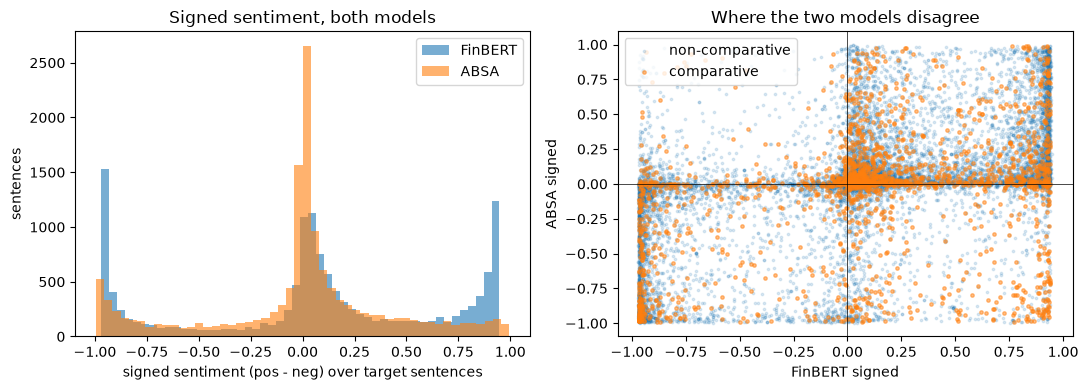

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(fin_signed, bins=50, alpha=0.6, label="FinBERT")
axes[0].hist(absa_signed, bins=50, alpha=0.6, label="ABSA")
axes[0].set_xlabel("signed sentiment (pos - neg) over target sentences")
axes[0].set_ylabel("sentences")
axes[0].set_title("Signed sentiment, both models")
axes[0].legend()

comp_mask = tgt["is_comparative"]
axes[1].scatter(fin_signed[~comp_mask], absa_signed[~comp_mask], s=3, alpha=0.15,
                label="non-comparative")
axes[1].scatter(fin_signed[comp_mask], absa_signed[comp_mask], s=6, alpha=0.5,
                label="comparative")
axes[1].axhline(0, lw=0.5, color="k")
axes[1].axvline(0, lw=0.5, color="k")
axes[1].set_xlabel("FinBERT signed")
axes[1].set_ylabel("ABSA signed")
axes[1].set_title("Where the two models disagree")
axes[1].legend()

plt.tight_layout()
fig.savefig(REPORTS_DIR / "figures" / "2.3-finbert-vs-absa.png", dpi=120)
plt.show()

In [18]:
# Sign disagreement, split by whether the sentence is a registry comparative.
disagree = ((fin_signed > 0) & (absa_signed < 0)) | ((fin_signed < 0) & (absa_signed > 0))
rate = pd.DataFrame({
    "n": [int((~comp_mask).sum()), int(comp_mask.sum())],
    "sign disagreement": [
        float(disagree[~comp_mask].mean()),
        float(disagree[comp_mask].mean()),
    ],
}, index=["non-comparative", "comparative"])
rate.round(4)

,n,sign disagreement
non-comparative,11892,0.2318
comparative,2055,0.3085


ABSA puts far more of the corpus in the neutral bucket than FinBERT does (neutral mean 0.660 against
0.443), which is what an aspect-scoped reading *should* do: most sentences that mention a company
are not expressing sentiment toward that company. The two signed scores correlate at **0.49** --
related, clearly not interchangeable.

The disagreement rates are the more interesting result, and they do not say quite what we expected:

| | n | outright sign disagreement |
|---|---|---|
| non-comparative | 11,892 | **23.2%** |
| comparative | 2,055 | **30.9%** |

Comparative sentences do disagree more, which is the predicted effect. But the base rate is the
finding: **the two models disagree on the sign of sentiment for nearly a quarter of ordinary,
non-comparative target sentences.** That is far too large to be explained by the 2,055 comparative
rows, and it is the same conclusion section 3.2's control list reached from the other direction --
the contamination `is_comparative` was built to catch is a small, visible corner of a much broader
disagreement between "what this sentence says" and "what this sentence says about Tesla".

It is worth being careful about what this number is *not*. A disagreement is not evidence that ABSA
is right; it only establishes that the choice between them is consequential. Section 3.2 is the only
evidence we have about *who* is right, and it is 25 hand-adjudicated sentences.

In plain terms: the two models genuinely read a lot of sentences differently -- often enough that
picking one over the other will visibly move the features. Which is exactly why we are not going to
pick one on the evidence we currently have.

## 7. Does ABSA become the primary entity-scoped scorer?

**Recommendation: yes in intent, no in action -- not yet, and the reason is the point of section 9.**

The evidence for ABSA is real and one-directional. On every hand-adjudicated disagreement we have
looked at -- 15 comparative sentences, then a 10-sentence control list built specifically to find a
domain-mismatch penalty -- ABSA was right and FinBERT was wrong, and the control list widened the
problem rather than narrowing it. There is no case yet where FinBERT's sentence-level reading was
the better answer for the question this pipeline asks.

But "ABSA won 25 hand-picked disagreements" is not the same claim as "ABSA produces better features",
and we cannot currently tell the difference. Those 25 were chosen *because* the models disagreed,
which is the most favourable possible sample for whichever model is right about disagreements.

Section 6 makes that gap much harder to wave away than it looked at the start of this notebook. The
two models disagree on the *sign* of sentiment for **23.2%** of non-comparative target sentences --
roughly 2,800 sentences in this corpus. We have hand-adjudicated 25 of them. Whatever we believe
about the other ~2,775 is extrapolation from a sample chosen for being favourable, and the honest
summary is that the choice between the two models is high-stakes and essentially unmeasured.

So the decision is to **keep both column families** and let the first downstream metric choose. That
is not fence-sitting; it is the cheapest option available. With warm caches the combined marginal
cost of carrying both is under two seconds per run, and the columns are already built to be swapped:
every `absa_*` feature reads exactly the same sentence selection as its `sent_*` twin, so a model
that prefers one family needs no pipeline change at all. Deleting the FinBERT columns now would buy
nothing and would destroy the comparison before anything has been measured against returns.

In plain terms: we think the aspect model is the right one, everything we have checked by hand says
so, and it costs us nothing to keep both until we have a number that can actually settle it.

## 8. Limitations, stated plainly

- **Coreference is not solved, only improved.** Roughly 17% of articles yield no usable coref
  clusters and fall through entirely to the heuristic. Section 4 is the direct evidence that the
  clusters it does produce contain real errors -- countries, products and other companies dragged
  into a Tesla chain. The guard stops those from corrupting the *text* we score; it does not stop
  them from setting the tag in the first place, so a residue of sentences are called Tesla sentences
  on a coreference mistake.
- **The guard is surface-shaped, so a handful of wrong referents still pass it.** "the Chinese EV
  maker", "the South Korean corporation" and "the rocket maker's" are perfectly well-formed company
  anaphors that happen to denote BYD, Samsung and SpaceX. Distinguishing them from "the EV maker"
  requires knowing which company is under discussion, which is the very thing coreference got wrong.
  About ten such singletons survive in the corpus.
- **Boilerplate detection is exact-text only.** Syndicated sentences appearing in three or four
  articles slip under the five-article threshold.
- ~~**`mentions_other` carries meaningful NER noise**, which pollutes `sent_other_mean_*`.~~
  **RESOLVED**, by taking the option this bullet describes: other-company detection is now
  registry-only. `sent_other_mean_*` became precise but narrower, with more articles NaN. See the
  superseded banner in 1.2 for why it was done without waiting for the metric this bullet was
  deferring to -- ABSA removed the need for the detector rather than the metric settling its value.
- **Descriptor scoping depends on registry coverage.** A descriptor borne by an unregistered company
  resolves to nothing.
- **One aspect per row.** A comparative sentence is both a target row and an other row but carries a
  single aspect, and gets the *target* one. That is the right choice given the motivation, but it
  means such rows contribute a target-aspect score to `absa_other_mean_*`.
- **Reproducibility floor ~2.4e-6.** FinBERT float32 inference is batch-composition dependent, so
  compare feature tables across runs with an **absolute** tolerance around 1e-5 -- not equality, and
  not a *relative* tolerance. 2.1 section 8 records how we found this.

## 9. The gap that matters more than any of this

**There is still no downstream metric.** Every validation in this project -- including this
notebook -- is an eyeball check or a hand-adjudicated sample. `LABEL_HORIZONS_DAYS = [1, 3]` has sat
in `config.py` since the beginning and nothing measures whether any of these features predict
returns. Six waves of NLP work have been graded on whether the output *reads* better.

That is a real risk and worth naming precisely: every improvement documented above is an improvement
in *fidelity to what the sentence says*, which we have simply assumed is the same thing as
predictive value. It might not be. It is entirely possible that FinBERT's noisier, sentence-level
reading carries as much return-predictive signal as ABSA's more faithful one, and nothing here would
detect that.

Two things close the gap, in order of cost:

1. **A gold set** -- a few hundred sentences, stratified across the mechanisms that produced their
   tags, labelled by hand for sentiment *toward the target*. That converts "ABSA won 25 adjudicated
   disagreements" into an accuracy number with a denominator. The sampler is built below.
2. **The returns-labelling and evaluation path** -- join articles to OHLCV, compute forward returns
   at the configured horizons, and measure whether any feature family carries signal. This is the
   one that actually settles section 7, and it is the next piece of work.

### 9.1 The gold-set sampler

`stock_predictor/text/goldset.py` built the stratified sample and a blank annotation sheet (the
module has since been removed — see the note below). It deliberately labelled nothing: a machine-generated label would make the resulting accuracy number
circular. The sheet also withholds every model output -- an annotator shown the model's answer
agrees with it, and we would end up measuring agreement rather than correctness.

> **SUPERSEDED — the gold set was never labelled, and has been removed.**
> The sampler cell that stood here called `stock_predictor/text/goldset.py`, which no longer
> exists, so it has been deleted rather than left to raise on re-execution. The 300 sampled rows
> were never annotated.
>
> **What replaced it.** Notebook 2.6 answered the same question — *is the tagging right?* — and
> answered it better: it audits the mechanisms directly (coreference at 93.5% correct referent, the
> anaphora heuristic at 13%, which is why that heuristic is now off) with a context window the
> judge can actually reason over. The gold set's own design flaw is visible in the paragraph below:
> it deliberately presented anaphora and coref rows **without** article context, which is precisely
> the mistake 2.6 documents as invalidating its own first attempt.
>
> `references/goldset-*` and `tests/test_goldset.py` went with it.

*(The paragraph below describes the removed design, and is kept because the flaw it documents is
the reason 2.6 exists.)* The labelling protocol was in `references/goldset-protocol.md`. The
`unclear` label is the one to
watch: the anaphora and coreference strata are presented **without** their article context by
design, so a high `unclear` rate in those strata is not a labelling failure -- it is a measurement of
how much those mechanisms are inferring that the sentence itself does not support.

In plain terms: we have spent six waves making the pipeline read sentences more like a person would,
and we still cannot say whether that makes the model predict better. The next piece of work is the
one that can.

## 10. Wrapping up

What this notebook did:

- documented Waves 4-6 -- keeping the parse, coreference, and aspect-based sentiment -- with the
  reasoning behind each tightening, not just the change;
- **audited the ABSA substitution against a fresh sample and found a fifth defect class** that the
  previous session's four fixes did not cover, added a guard, and re-ran;
- re-ran the full pipeline and rewrote `data/sentences.parquet` and `data/articles.parquet` behind
  the timestamp-integrity gate;
- compared FinBERT and ABSA across the whole corpus rather than on adjudicated anecdotes;
- recommended keeping both scorers until a downstream metric can choose, and said why that is the
  cheap option rather than the indecisive one;
- built the gold-set sampler and protocol so the next session can start labelling rather than
  building.

What it did not do, and what comes next: the returns-labelling and evaluation path. Until that
exists, every quality claim in this notebook -- including the ones we are most confident about -- is
a claim about how the output reads, not about whether it predicts anything.